<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Installing Dependencies
</h2>
</div>

In [ ]:
# !pip uninstall -y tensorflow tensorflow-intel protobuf bert-score evaluate
# !pip install protobuf==6.31.1 transformers==4.51.3 evaluate==0.4.3 bert-score==0.3.13 sentencepiece accelerate datasets

In [2]:
import torch, transformers, bert_score, evaluate
print(torch.__version__)
print(transformers.__version__)
print(bert_score.__version__)
print(evaluate.__version__)

2.13.0+cpu
4.51.3
0.3.12
0.4.3


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
dataset = pd.read_csv("agriculture_llm_evaluation_500.csv")
dataset.head()

,question,reference,non_instruction,instruction,preference
0,How can Tip over or Heart rot in banana plants...,Effective management of Tip over or Heart rot ...,NaN,How can the disease Tip over or heart rot in b...,How to grow bananas in a pot?
1,what food products can be made from corn meal.,"tortillas, bread, porridge, and other baked goods",NaN,Cornmeal is used to make a variety of deliciou...,"Cornmeal is a staple in many households, and i..."
2,how was harvesting done before the evolution o...,Gathering and removing mature plants from the ...,NaN,- farmers would have to wait for the crops to ...,I'm not sure if this is a good question to ask...
3,why DK maize variety widely grown in Uganda.,"It is known for its high yield potential, good...",The DK maize variety is widely grown in Uganda...,Why does maize varieties like DK uganda grow w...,1.1.2.3. The study was conducted in the year 2...
4,which organic matter help improve soil fertility.,compost or well-rotted manure,NaN,NaN,The most important thing to remember is that t...


In [4]:
dataset["non_instruction"] = dataset["non_instruction"].fillna("")
dataset["instruction"] = dataset["instruction"].fillna("")
dataset["preference"] = dataset["preference"].fillna("")
dataset["reference"] = dataset["reference"].fillna("")

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Bleu Score
</h2>
</div>

In [6]:
from sacrebleu import sentence_bleu
from tqdm.auto import tqdm

def calculate_bleu(predictions,references):
    scores=[]
    for pred,ref in tqdm(zip(predictions,references),total=len(predictions),desc="BLEU"):
        pred,ref=str(pred).strip(),str(ref).strip()
        if not pred or not ref: scores.append(0); continue
        scores.append(sentence_bleu(pred,[ref]).score/100)
    return sum(scores)/len(scores)

references=dataset["reference"].fillna("").tolist()

print("Calculating DAPT BLEU...")
dapt_bleu=calculate_bleu(dataset["non_instruction"].fillna("").tolist(),references)

print("Calculating SFT BLEU...")
sft_bleu=calculate_bleu(dataset["instruction"].fillna("").tolist(),references)

print("Calculating DPO BLEU...")
dpo_bleu=calculate_bleu(dataset["preference"].fillna("").tolist(),references)

print(f"DAPT BLEU : {dapt_bleu:.4f}")
print(f"SFT BLEU  : {sft_bleu:.4f}")
print(f"DPO BLEU  : {dpo_bleu:.4f}")

Calculating DAPT BLEU...


BLEU:   0%|          | 0/500 [00:00<?, ?it/s]

Calculating SFT BLEU...


BLEU:   0%|          | 0/500 [00:00<?, ?it/s]

Calculating DPO BLEU...


BLEU:   0%|          | 0/500 [00:00<?, ?it/s]

DAPT BLEU : 0.0080
SFT BLEU  : 0.0369
DPO BLEU  : 0.0103


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Rouge Score
</h2>
</div>

In [7]:
import evaluate

rouge=evaluate.load("rouge")
def calculate_rouge(predictions,references):
    return rouge.compute(predictions=predictions,references=references)
references=dataset["reference"].fillna("").astype(str).tolist()

dapt_rouge=calculate_rouge(dataset["non_instruction"].fillna("").astype(str).tolist(),references)
sft_rouge=calculate_rouge(dataset["instruction"].fillna("").astype(str).tolist(),references)
dpo_rouge=calculate_rouge(dataset["preference"].fillna("").astype(str).tolist(),references)

print("DAPT ROUGE:",dapt_rouge)
print("SFT ROUGE :",sft_rouge)
print("DPO ROUGE :",dpo_rouge)

DAPT ROUGE: {'rouge1': np.float64(0.06703860677548189), 'rouge2': np.float64(0.012125675839474045), 'rougeL': np.float64(0.04872887031595703), 'rougeLsum': np.float64(0.05102269047232287)}
SFT ROUGE : {'rouge1': np.float64(0.14846155422719154), 'rouge2': np.float64(0.051911656578185916), 'rougeL': np.float64(0.12220215207478323), 'rougeLsum': np.float64(0.1238596349180476)}
DPO ROUGE : {'rouge1': np.float64(0.10284145746511907), 'rouge2': np.float64(0.018465749286297586), 'rougeL': np.float64(0.07627058476299597), 'rougeLsum': np.float64(0.08045173554594157)}


In [9]:
# !pip install -U bert-score

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
BERT F1 Score
</h2>
</div>

In [8]:
import evaluate

bertscore = evaluate.load("bertscore")

def calculate_bert_score(predictions, references):
    result = bertscore.compute(
        predictions=predictions,
        references=references,
        lang="en"
    )
    return sum(result["f1"]) / len(result["f1"])

def get_data(column):
    df = dataset.dropna(subset=[column, "reference"])
    return df[column].astype(str).tolist(), df["reference"].astype(str).tolist()

dapt_pred, dapt_ref = get_data("non_instruction")
sft_pred, sft_ref = get_data("instruction")
dpo_pred, dpo_ref = get_data("preference")

dapt_bert = calculate_bert_score(dapt_pred, dapt_ref)
sft_bert = calculate_bert_score(sft_pred, sft_ref)
dpo_bert = calculate_bert_score(dpo_pred, dpo_ref)

print(f"DAPT BERTScore : {dapt_bert:.4f}")
print(f"SFT BERTScore  : {sft_bert:.4f}")
print(f"DPO BERTScore  : {dpo_bert:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DAPT BERTScore : 0.4478
SFT BERTScore  : 0.7019
DPO BERTScore  : 0.8211


<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Creating CSV File for evaluation result
</h2>
</div>

In [10]:
import pandas as pd

evaluation_results=pd.DataFrame({
    "Model":["TinyLlama-DAPT","TinyLlama-SFT","TinyLlama-DPO"],
    "BERTScore":[dapt_bert,sft_bert,dpo_bert],
    "ROUGE-1":[dapt_rouge["rouge1"],sft_rouge["rouge1"],dpo_rouge["rouge1"]],
    "ROUGE-2":[dapt_rouge["rouge2"],sft_rouge["rouge2"],dpo_rouge["rouge2"]],
    "ROUGE-L":[dapt_rouge["rougeL"],sft_rouge["rougeL"],dpo_rouge["rougeL"]],
})

evaluation_results

,Model,BERTScore,ROUGE-1,ROUGE-2,ROUGE-L
0,TinyLlama-DAPT,0.447779,0.067039,0.012126,0.048729
1,TinyLlama-SFT,0.701879,0.148462,0.051912,0.122202
2,TinyLlama-DPO,0.821111,0.102841,0.018466,0.076271


In [11]:
evaluation_results.to_csv("Agriculture_DAPT_SFT_DPO_Evaluation_Metrics.csv",index=False)

<div style="background-color:#E8F8F5; padding:20px; border-radius:10px; text-align:center;">
<h2 style="color:#117864;">
Visualizing Result for Comparison
</h2>
</div>

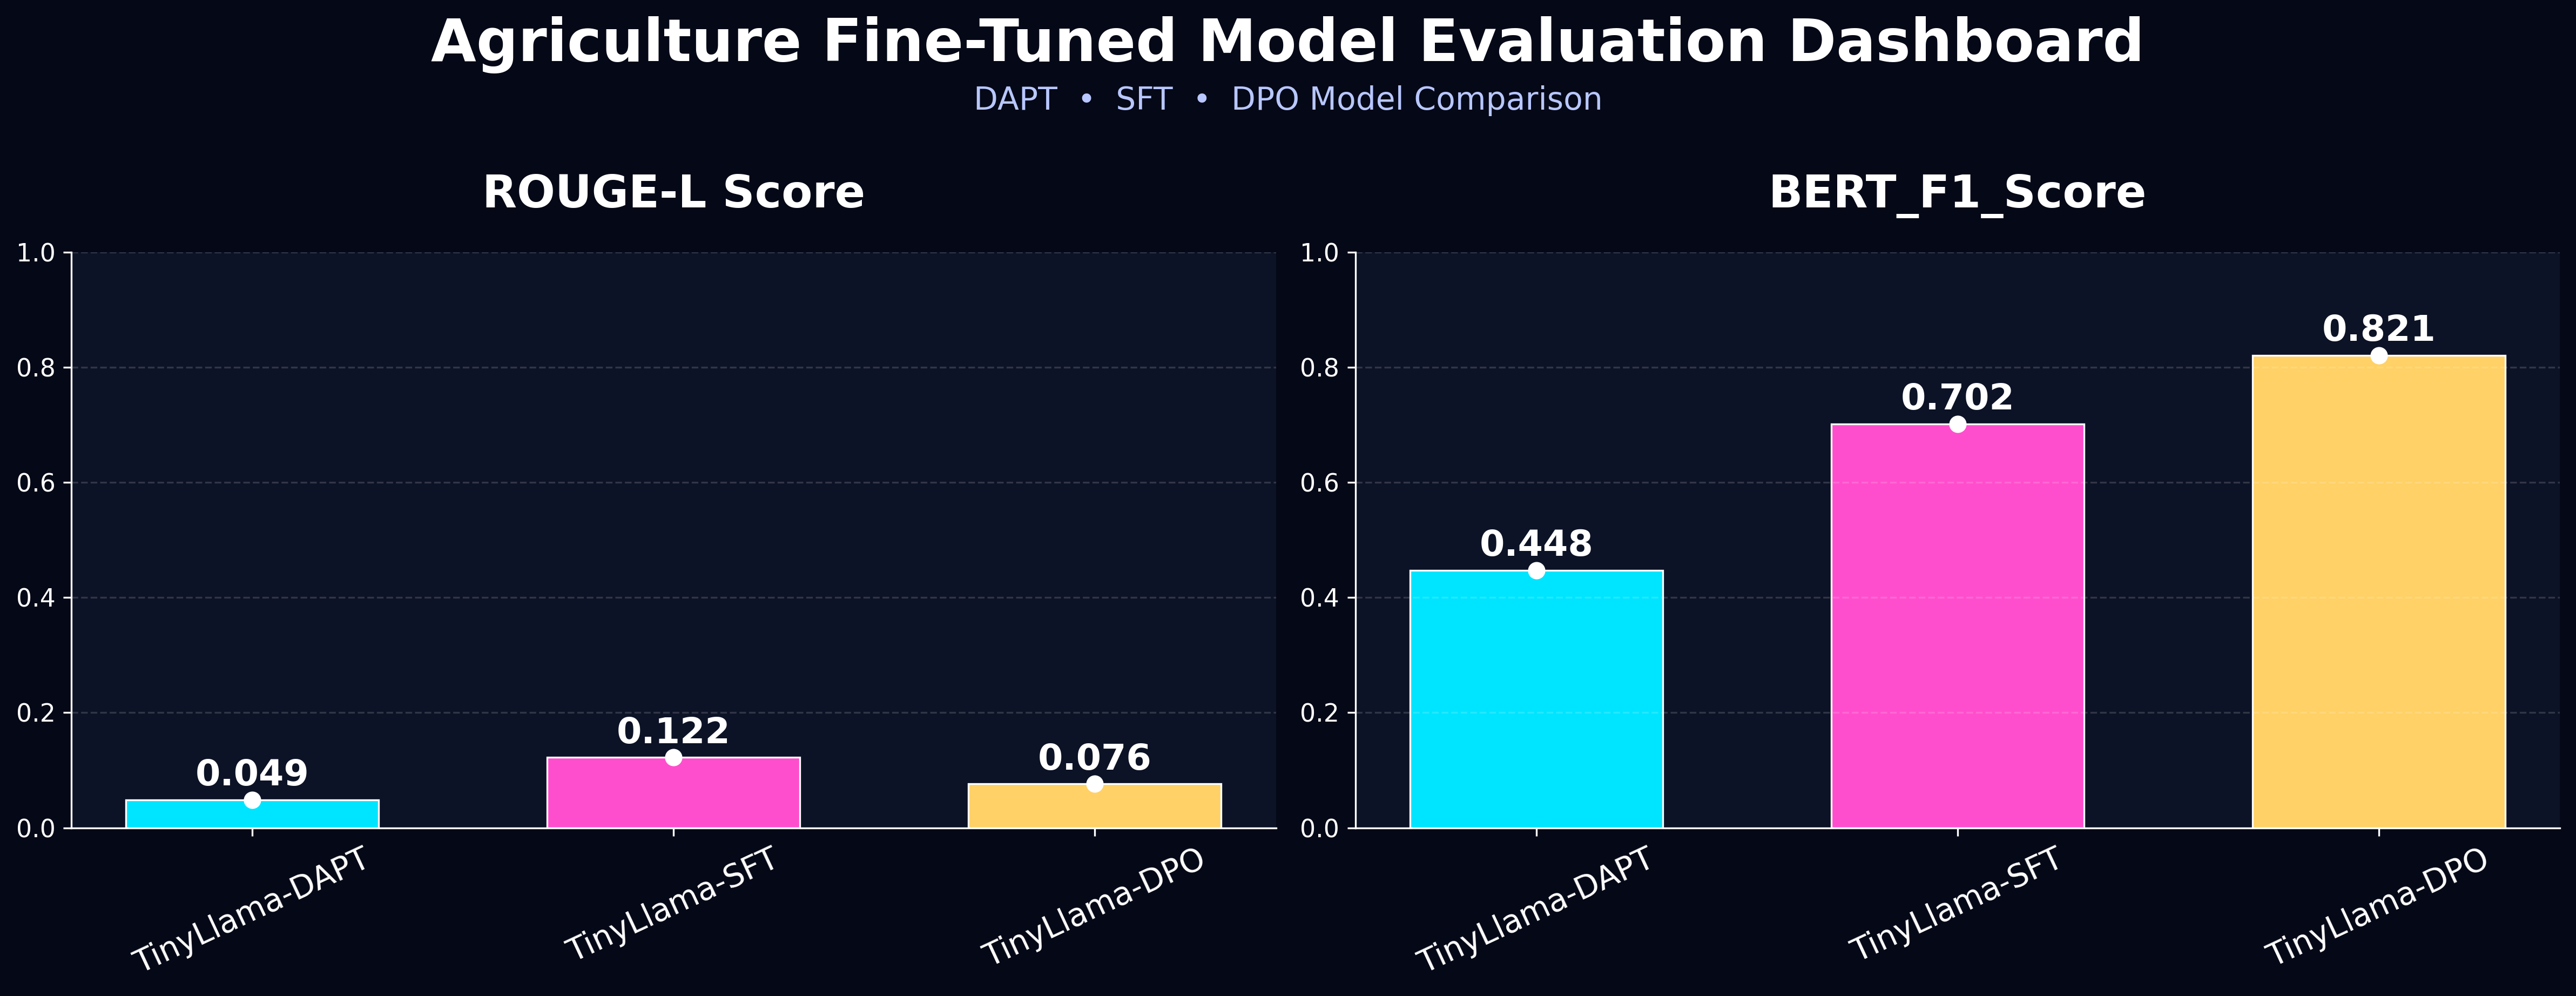

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("Agriculture_DAPT_SFT_DPO_Evaluation_Metrics.csv")
models=df["Model"]
plt.style.use("dark_background")
fig,ax=plt.subplots(1,2,figsize=(16,6),dpi=300)
fig.patch.set_facecolor("#050816")

palette=["#00E5FF","#FF4ECD","#FFD166"]
for i,m in enumerate(["ROUGE-L","BERTScore"]):
    ax[i].set_facecolor("#0D1326")
    bars=ax[i].bar(models,df[m],color=palette,width=0.6,edgecolor="#FFFFFF",linewidth=0.8)

    for b,v in zip(bars,df[m]):
        ax[i].text(b.get_x()+b.get_width()/2,v+0.025,f"{v:.3f}",ha="center",fontsize=16,fontweight="bold",color="white")
        ax[i].scatter(b.get_x()+b.get_width()/2,v,s=45,color="white",zorder=3)

    ax[i].set_title("BERT_F1_Score" if m=="BERTScore" else f"{m} Score",fontsize=20,fontweight="bold",color="white",pad=20)
    ax[i].set_ylim(0,1)
    ax[i].tick_params(axis="x",rotation=25,labelsize=14)
    ax[i].tick_params(axis="y",labelsize=11)
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].grid(axis="y",alpha=0.15,linestyle="--")

fig.text(0.5,0.97,"Agriculture Fine-Tuned Model Evaluation Dashboard",ha="center",fontsize=26,fontweight="bold",color="white")
fig.text(0.5,0.92,"DAPT  •  SFT  •  DPO Model Comparison",ha="center",fontsize=14,color="#B8C7FF")

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig("Agriculture Fine-Tuned Model Evaluation Dashboard.png",dpi=300,bbox_inches="tight",facecolor=fig.get_facecolor())

plt.show()

<div style="background-color:#E8F8F5; padding:25px; border-radius:10px; text-align:center;">

<h2 style="color:#117864; font-weight:700; font-size:34px; margin-bottom:20px;">
🙏 Thank You!
</h2>

<p style="color:#000000; font-size:17px; line-height:1.8; text-align:center; margin:0;">
Thank you for taking the time to explore this notebook. ❤️ I hope you found it informative and valuable.
</p>

<p style="color:#117864; font-weight:700; font-size:20px; margin-bottom:20px;text-align:center;">
🚀Happy Coding!
</p>


</div>